# Phase 4: Evaluation & Application

| ส่วน | เนื้อหา |
|---|---|
| **4.1** | Precision / Recall / F1 + Error Analysis + Embedding vs BoW |
| **4.2** | Document Search ด้วย Cosine Similarity (Bonus) |

> **วิธีใช้:** รัน Phase 3 ให้ครบก่อน (เพื่อ save model) แล้วค่อยรัน Notebook นี้

---
## ขั้นตอนที่ 1 — Import และโหลด Artifacts (model, tokenizer, และ .npy files)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.manifold import TSNE

print("✅ Imports สำเร็จ")

✅ Imports สำเร็จ


In [19]:
# =========================================================
# โหลด artifacts จาก Phase 3
# =========================================================
model     = load_model("Models/phase3_lstm_model.keras")
max_len   = 100

with open("Models/phase3_tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# predictions จาก Phase 3
y_test_A   = np.load("Models/phase3_y_test_A.npy", allow_pickle=True)
y_pred_A   = np.load("Models/phase3_y_pred_A.npy", allow_pickle=True)
y_test_B   = np.load("Models/phase3_y_test_B.npy", allow_pickle=True)
y_pred_B   = np.load("Models/phase3_y_pred_B.npy", allow_pickle=True)
x_test_padB = np.load("Models/phase3_x_test_padB.npy")

# label mapping (ให้ model B ใช้ string labels เหมือน A)
label_map  = {0: "negative", 1: "neutral", 2: "positive"}
y_test_B_str  = np.array([label_map[i] for i in y_test_B])
y_pred_B_str  = np.array([label_map[i] for i in y_pred_B])

class_names = ["negative", "neutral", "positive"]

# โหลด full dataset สำหรับ error analysis และ document search
df         = pd.read_csv("NLP Dataset/complete_dataset_(Labeling).csv")
all_texts  = df["Sentence"].tolist()
all_labels = df["Sentiment"].tolist()

print("✅ โหลดทุก artifact สำเร็จ")
print(f"   Test set A: {len(y_test_A)} samples")
print(f"   Test set B: {len(y_test_B)} samples")

✅ โหลดทุก artifact สำเร็จ
   Test set A: 1337 samples
   Test set B: 1337 samples


---
# 4.1 Evaluation
## 4.1.1 Classification Report — Precision, Recall, F1

In [20]:
print("=" * 65)
print("📊 MODEL A — Classic: TF-IDF + Logistic Regression")
print("=" * 65)
print(classification_report(y_test_A, y_pred_A, target_names=class_names))

print("=" * 65)
print("🧠 MODEL B — Neural: Embedding + Bidirectional LSTM")
print("=" * 65)
print(classification_report(y_test_B_str, y_pred_B_str, target_names=class_names))

📊 MODEL A — Classic: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.39      0.47      0.42       180
     neutral       0.77      0.73      0.75       728
    positive       0.70      0.71      0.70       429

    accuracy                           0.69      1337
   macro avg       0.62      0.63      0.63      1337
weighted avg       0.70      0.69      0.69      1337

🧠 MODEL B — Neural: Embedding + Bidirectional LSTM
              precision    recall  f1-score   support

    negative       0.35      0.46      0.40       180
     neutral       0.80      0.69      0.74       728
    positive       0.65      0.73      0.69       429

    accuracy                           0.67      1337
   macro avg       0.60      0.62      0.61      1337
weighted avg       0.69      0.67      0.68      1337



In [21]:
# ตารางเปรียบเทียบ F1 ต่อ class
f1_A = f1_score(y_test_A,     y_pred_A,     labels=class_names, average=None)
f1_B = f1_score(y_test_B_str, y_pred_B_str, labels=class_names, average=None)
p_A  = precision_score(y_test_A,     y_pred_A,     labels=class_names, average=None)
p_B  = precision_score(y_test_B_str, y_pred_B_str, labels=class_names, average=None)
r_A  = recall_score(y_test_A,     y_pred_A,     labels=class_names, average=None)
r_B  = recall_score(y_test_B_str, y_pred_B_str, labels=class_names, average=None)

compare_df = pd.DataFrame({
    "Class":              class_names,
    "Classic — P":        p_A.round(3),
    "Classic — R":        r_A.round(3),
    "Classic — F1":       f1_A.round(3),
    "Neural  — P":        p_B.round(3),
    "Neural  — R":        r_B.round(3),
    "Neural  — F1":       f1_B.round(3),
    "F1 Diff (B − A)":   (f1_B - f1_A).round(3),
})

def highlight_diff(val):
    if val > 0.03:  return "background-color:#d4edda"
    if val < -0.03: return "background-color:#f8d7da"
    return ""

display(compare_df.style.map(highlight_diff, subset=["F1 Diff (B − A)"]))

macro_A = f1_score(y_test_A,     y_pred_A,     average="macro")
macro_B = f1_score(y_test_B_str, y_pred_B_str, average="macro")
winner  = "Classic (A)" if macro_A > macro_B else "Neural (B)"
print(f"\nMacro F1 — Classic : {macro_A:.4f}")
print(f"Macro F1 — Neural  : {macro_B:.4f}")
print(f"🏆 โมเดลที่ชนะ: {winner}")

,Class,Classic — P,Classic — R,Classic — F1,Neural — P,Neural — R,Neural — F1,F1 Diff (B − A)
0,negative,0.389000,0.467000,0.424000,0.353000,0.456000,0.398000,-0.026000
1,neutral,0.770000,0.729000,0.749000,0.799000,0.687000,0.739000,-0.010000
2,positive,0.703000,0.706000,0.705000,0.651000,0.727000,0.687000,-0.017000



Macro F1 — Classic : 0.6259
Macro F1 — Neural  : 0.6079
🏆 โมเดลที่ชนะ: Classic (A)


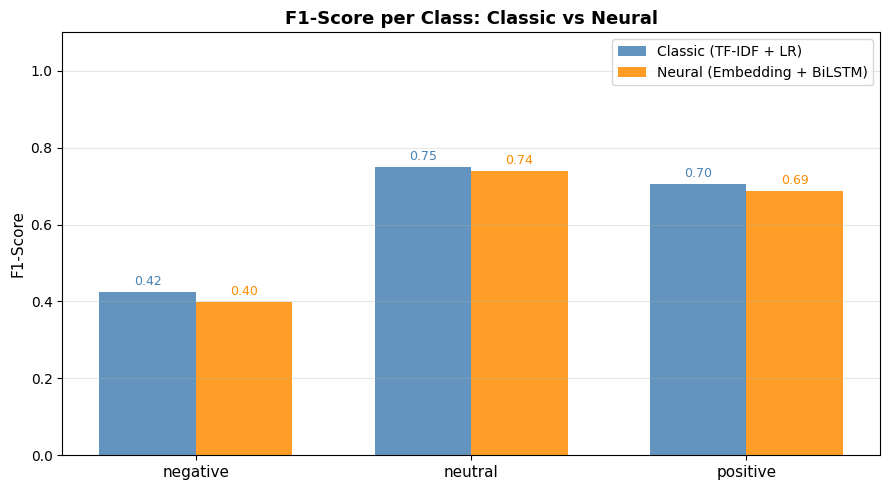

In [22]:
# Bar chart เปรียบเทียบ F1 ต่อ class
x     = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_A = ax.bar(x - width/2, f1_A, width, label="Classic (TF-IDF + LR)",
                color="steelblue", alpha=0.85)
bars_B = ax.bar(x + width/2, f1_B, width, label="Neural (Embedding + BiLSTM)",
                color="darkorange", alpha=0.85)

for bars, color in [(bars_A, "steelblue"), (bars_B, "darkorange")]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom",
                fontsize=9, color=color)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("F1-Score per Class: Classic vs Neural", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

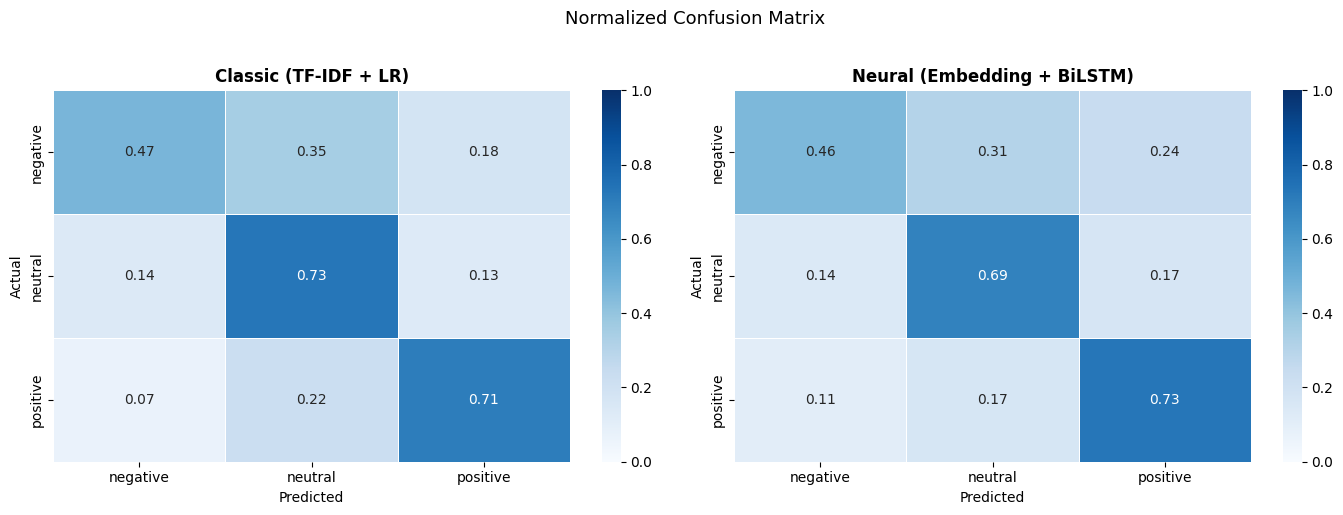

In [23]:
# Confusion Matrix ทั้ง 2 โมเดล
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, y_pred, title in zip(
    axes,
    [y_test_A,     y_test_B_str],
    [y_pred_A,     y_pred_B_str],
    ["Classic (TF-IDF + LR)", "Neural (Embedding + BiLSTM)"]
):
    cm      = confusion_matrix(y_true, y_pred, labels=class_names)
    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual",    fontsize=10)

plt.suptitle("Normalized Confusion Matrix", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4.1.2 Error Analysis
> วิเคราะห์ว่าโมเดลไหนชนะ และตรงไหนที่แต่ละโมเดลทำพลาด

In [24]:
# =========================================================
# โหลด test texts จาก Phase 3 สำหรับ error analysis
# (ใช้ split เดิมจาก Phase 3 — random_state=12 สำหรับ A, 21 สำหรับ B)
# =========================================================
from sklearn.model_selection import train_test_split

df_raw = pd.read_csv("NLP Dataset/complete_dataset_(Labeling).csv")

# reconstruct test set A texts
_, x_test_texts_A, _, _ = train_test_split(
    df_raw["Sentence"], df_raw["Sentiment"],
    test_size=0.2, random_state=12, stratify=df_raw["Sentiment"]
)
test_texts_A = x_test_texts_A.tolist()

# reconstruct test set B texts
df_raw["Sentiment_num"] = df_raw["Sentiment"].map({"negative": 0, "neutral": 1, "positive": 2})
_, x_test_texts_B, _, _ = train_test_split(
    df_raw["Sentence"], df_raw["Sentiment_num"],
    test_size=0.2, random_state=21, stratify=df_raw["Sentiment_num"]
)
test_texts_B = x_test_texts_B.tolist()

print(f"✅ Test texts โหลดสำเร็จ — A: {len(test_texts_A)}, B: {len(test_texts_B)}")

✅ Test texts โหลดสำเร็จ — A: 1337, B: 1337


In [25]:
# =========================================================
# สรุปจำนวน error แต่ละประเภท (เทียบกัน)
# =========================================================

# ใช้ test set ที่ label map กลับมาเป็น string แล้ว
# (ทั้ง A และ B ใช้ string labels เพื่อเปรียบกัน)

# error patterns ของ A
errors_A = [(y_test_A[i], y_pred_A[i])
            for i in range(len(y_test_A)) if y_test_A[i] != y_pred_A[i]]
error_counts_A = pd.Series(errors_A).value_counts().head(5)

# error patterns ของ B
errors_B = [(y_test_B_str[i], y_pred_B_str[i])
            for i in range(len(y_test_B_str)) if y_test_B_str[i] != y_pred_B_str[i]]
error_counts_B = pd.Series(errors_B).value_counts().head(5)

total_A = len(y_test_A)
total_B = len(y_test_B_str)
wrong_A = sum(y_test_A[i] != y_pred_A[i] for i in range(total_A))
wrong_B = sum(y_test_B_str[i] != y_pred_B_str[i] for i in range(total_B))

print(f"📊 Error Summary")
print(f"   Classic (A): ผิด {wrong_A}/{total_A} ({wrong_A/total_A*100:.1f}%)")
print(f"   Neural  (B): ผิด {wrong_B}/{total_B} ({wrong_B/total_B*100:.1f}%)")

print(f"\n📋 Top 5 คู่ class ที่ Classic (A) สับสนมากสุด:")
for (actual, pred), count in error_counts_A.items():
    print(f"   actual={actual:8s} → pred={pred:8s} : {count} ครั้ง")

print(f"\n📋 Top 5 คู่ class ที่ Neural (B) สับสนมากสุด:")
for (actual, pred), count in error_counts_B.items():
    print(f"   actual={actual:8s} → pred={pred:8s} : {count} ครั้ง")

📊 Error Summary
   Classic (A): ผิด 419/1337 (31.3%)
   Neural  (B): ผิด 443/1337 (33.1%)

📋 Top 5 คู่ class ที่ Classic (A) สับสนมากสุด:
   actual=neutral  → pred=negative : 102 ครั้ง
   actual=positive → pred=neutral  : 96 ครั้ง
   actual=neutral  → pred=positive : 95 ครั้ง
   actual=negative → pred=neutral  : 63 ครั้ง
   actual=negative → pred=positive : 33 ครั้ง

📋 Top 5 คู่ class ที่ Neural (B) สับสนมากสุด:
   actual=neutral  → pred=positive : 124 ครั้ง
   actual=neutral  → pred=negative : 104 ครั้ง
   actual=positive → pred=neutral  : 71 ครั้ง
   actual=negative → pred=neutral  : 55 ครั้ง
   actual=positive → pred=negative : 46 ครั้ง


In [26]:
# ตัวอย่างข้อความที่ Classic ทำผิด — negative ถูก predict เป็น neutral
print("\n🔍 ตัวอย่าง: Classic (A) ผิด — actual=negative, pred=neutral")
print("-" * 65)
count = 0
for i in range(len(y_test_A)):
    if y_test_A[i] == "negative" and y_pred_A[i] == "neutral":
        print(f"Text: {test_texts_A[i][:180]}")
        print(f"  actual={y_test_A[i]}  pred={y_pred_A[i]}")
        print("-" * 65)
        count += 1
        if count >= 5:
            break


🔍 ตัวอย่าง: Classic (A) ผิด — actual=negative, pred=neutral
-----------------------------------------------------------------
Text: As part of the reorganisation measures that will take place in spring 2006 , Tamglass Finton will start personnel negotiations that will affect its entire staff of 33 .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: When this information was released on 5 September 2008 , Nokia 's American Depositary shares fell by 8 % .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: According to the company , in addition to normal seasonal fluctuation the market situation has weakened during autumn 2008 .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: At the moment , Valio is not worried , but if the ban continues for long , it may become quite a problem .
  actual=negative  pred=neutral
---------------

In [27]:
# ตัวอย่างข้อความที่ Neural ทำผิด — negative ถูก predict เป็น neutral
print("\n🔍 ตัวอย่าง: Neural (B) ผิด — actual=negative, pred=neutral")
print("-" * 65)
count = 0
for i in range(len(y_test_B_str)):
    if y_test_B_str[i] == "negative" and y_pred_B_str[i] == "neutral":
        print(f"Text: {test_texts_B[i][:180]}")
        print(f"  actual={y_test_B_str[i]}  pred={y_pred_B_str[i]}")
        print("-" * 65)
        count += 1
        if count >= 5:
            break


🔍 ตัวอย่าง: Neural (B) ผิด — actual=negative, pred=neutral
-----------------------------------------------------------------
Text: According to the company , in addition to normal seasonal fluctuation the market situation has weakened during autumn 2008 .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: According to the Latvian business register , Uponor Latvia closed in red with LVL 99,000 EUR 139,538.17 USD 194,556.48 on turnover of LVL 2.346 mn for 2009 .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: Finland-based Stockmann Group has closed seven franchising sports stores Nike in Russia .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: Profit before taxes was EUR 4.0 mn , down from EUR 4.9 mn .
  actual=negative  pred=neutral
-----------------------------------------------------------------
Text: Belarus OAO Lidskoe

## 4.1.3 เปรียบเทียบ Word Embeddings vs Bag-of-Words (TF-IDF)

| มิติ | Bag-of-Words (TF-IDF) | Word Embeddings |
|---|---|---|
| **การแทน vector** | Sparse — มิติ = vocabulary size (หลายหมื่น) | Dense — มิติ = 128 เท่านั้น |
| **ความหมายของคำ** | ไม่รู้จัก — "ดี" กับ "เยี่ยม" เป็นคนละ feature อิสระ | รู้จัก — คำที่มีความหมายใกล้กันอยู่ใกล้กันใน vector space |
| **ลำดับคำ** | ไม่สนลำดับ | LSTM จับลำดับได้ ทำให้เข้าใจ context |
| **คำที่ไม่เคยเห็น (OOV)** | ถือว่าไม่มี | ใช้ `<OOV>` token แทน |
| **ความเร็ว train** | เร็วมาก | ช้ากว่า |
| **ตีความได้** | ง่าย — ดู feature importance ได้ | ยาก — เป็น black box |
| **เหมาะกับ** | dataset เล็ก / keyword-heavy | dataset ใหญ่ / ต้องการ semantic understanding |

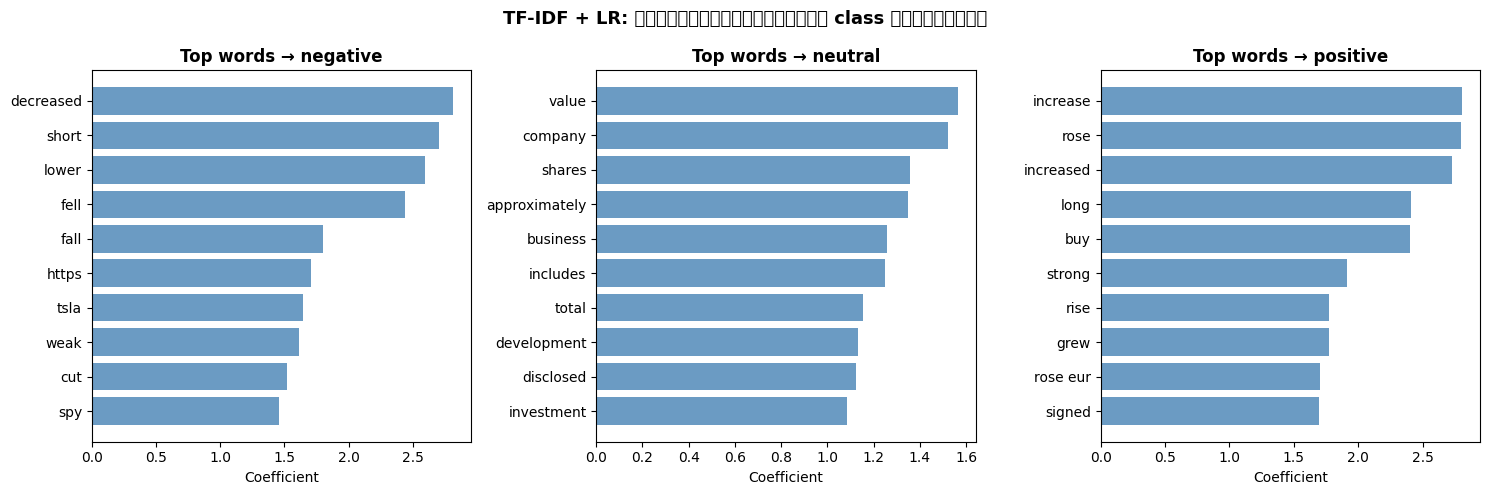

In [28]:
# =========================================================
# แสดง Top features ของ Logistic Regression (BoW)
# เพื่อแสดงว่า TF-IDF ตัดสินจากคำอะไร
# =========================================================
# import vectorizer จาก phase 3 (ต้องรัน phase 3 ก่อน หรือ save เพิ่มเติม)
# ถ้าไม่มี vectorizer ให้ comment section นี้ออกได้

try:
    with open("Models/phase3_vectorizer.pkl", "rb") as f:
        vectorizer_loaded = pickle.load(f)
    with open("Models/phase3_lr_model.pkl", "rb") as f:
        lr_model_loaded = pickle.load(f)

    feature_names = vectorizer_loaded.get_feature_names_out()
    n_top = 10

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, (cls, ax) in enumerate(zip(class_names, axes)):
        coef = lr_model_loaded.coef_[i]
        top_idx = np.argsort(coef)[-n_top:][::-1]
        ax.barh(feature_names[top_idx][::-1], coef[top_idx][::-1],
                color="steelblue", alpha=0.8)
        ax.set_title(f"Top words → {cls}", fontweight="bold")
        ax.set_xlabel("Coefficient")
    plt.suptitle("TF-IDF + LR: Top words influencing each class",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print("⚠️  ไม่พบไฟล์")

### สรุปการวิเคราะห์

**โมเดลที่ชนะ:** (ดูจาก Macro F1 ข้างบน)

**เหตุผลที่ Classic (TF-IDF + LR) มักทำได้ดีในชุดข้อมูลนี้:**
- ข้อความในชุดข้อมูลสั้นมาก (เช่น `"$BBRY nice bounce"`) TF-IDF จับ keyword ได้ตรงกว่า
- Dataset ขนาด ~6,600 ค่อนข้างเล็กสำหรับ Neural model ที่ train จาก scratch
- Neural model train เพียง 5 epochs อาจยัง underfit

**จุดที่ Neural เหนือกว่า:**
- Dense embedding ใช้ memory น้อยกว่ามาก (128-dim vs หมื่น-dim)
- สามารถนำ embedding ไปทำ Document Search ได้ (ดู 4.2)
- ถ้า train นานขึ้น หรือใช้ pretrained embedding (เช่น GloVe) จะดีกว่านี้มาก

**Class ที่ยากที่สุดสำหรับทั้งสองโมเดล:** `negative` — เพราะมีจำนวนน้อยที่สุด (class imbalance)

---
# 4.2 Document Search
## ระบบค้นหาเอกสารด้วย Neural Embeddings + Cosine Similarity

In [29]:
# สร้าง embedding encoder จาก model ที่โหลดมา
embedding_layer = model.layers[0]

def encode_texts(texts, tokenizer, embedding_layer, max_len=100, batch_size=256):
    all_vecs = []
    for start in range(0, len(texts), batch_size):
        batch  = texts[start : start + batch_size]
        seqs   = tokenizer.texts_to_sequences(batch)
        padded = pad_sequences(seqs, maxlen=max_len, padding="post")
        
        # ดึง Embedding ออกมา (shape: batch_size, max_len, embed_dim)
        embed  = embedding_layer(padded)
        
        # 1. สร้าง Mask บังคับให้ Padding = 0 และ คำจริง = 1
        mask = tf.cast(padded != 0, tf.float32) 
        mask_expanded = tf.expand_dims(mask, -1) 
        
        # 2. เอา Mask ไปคูณ เพื่อลบเวกเตอร์ของ Padding ให้กลายเป็น 0 ล้วน
        masked_embed = embed * mask_expanded
        
        # 3. หาผลรวมของเวกเตอร์ (เฉพาะคำจริงเพราะ Padding เป็น 0 ไปแล้ว)
        sum_embed = tf.reduce_sum(masked_embed, axis=1)
        
        # 4. นับจำนวนคำจริงในแต่ละประโยค (เพื่อเอาไปเป็นตัวหารค่าเฉลี่ย)
        valid_words_count = tf.reduce_sum(mask, axis=1, keepdims=True)
        valid_words_count = tf.maximum(valid_words_count, 1e-9) # กัน Error หารด้วยศูนย์
        
        # 5. หาค่าเฉลี่ยที่แท้จริง (Mean Pooling แบบข้าม Padding)
        pooled = sum_embed / valid_words_count
        
        all_vecs.append(pooled.numpy())
    return np.vstack(all_vecs)

print("กำลังสร้าง document vectors...")
doc_vectors = encode_texts(all_texts, tokenizer, embedding_layer, max_len=max_len)
norms       = np.linalg.norm(doc_vectors, axis=1, keepdims=True)
doc_vectors = doc_vectors / (norms + 1e-10)
print(f"✅ doc_vectors shape: {doc_vectors.shape}")

กำลังสร้าง document vectors...
✅ doc_vectors shape: (6681, 128)


In [ ]:
def search_documents(query, doc_vectors, texts, labels,
                     tokenizer, embedding_layer, max_len=100, top_k=5):
    # แปลง Query เป็น Sequence
    seq    = tokenizer.texts_to_sequences([query])
    padded = pad_sequences(seq, maxlen=max_len, padding="post")
    embed  = embedding_layer(padded)
    
    # ใช้วิธี Masking เดียวกันกับตอนสร้าง doc_vectors
    mask = tf.cast(padded != 0, tf.float32)
    mask_expanded = tf.expand_dims(mask, -1)
    masked_embed = embed * mask_expanded
    sum_embed = tf.reduce_sum(masked_embed, axis=1)
    valid_words = tf.maximum(tf.reduce_sum(mask, axis=1, keepdims=True), 1e-9)
    pooled = sum_embed / valid_words
    
    # ปรับเวกเตอร์ให้มีขนาดเป็น 1 (Normalize)
    q_vec  = pooled.numpy()[0]
    q_vec  = q_vec / (np.linalg.norm(q_vec) + 1e-10)

    # ค้นหาด้วย Cosine Similarity (Dot Product)
    scores  = doc_vectors.dot(q_vec)
    top_idx = np.argsort(scores)[::-1][:top_k]

    return pd.DataFrame([{
        "Rank":      rank,
        "Score":     round(float(scores[idx]), 4),
        "Sentiment": labels.iloc[idx] if isinstance(labels, pd.Series) else labels[idx], # ป้องกัน Error หาก labels เป็น Pandas Series
        "Document":  texts.iloc[idx][:200] + ("..." if len(texts.iloc[idx]) > 200 else "") if isinstance(texts, pd.Series) else texts[idx][:200] + ("..." if len(texts[idx]) > 200 else "")
    } for rank, idx in enumerate(top_idx, 1)])

print("✅ search_documents พร้อม")

✅ search_documents พร้อม


In [34]:
test_queries = [
    ("interest rates rise inflation economic growth", "🔴 คาดว่าจะเจอข่าว negative"),
    ("stock market gains profits quarterly earnings", "🟢 คาดว่าจะเจอข่าว positive"),
    ("central bank policy meeting announcement",      "🟡 คาดว่าจะเจอข่าว neutral"),
]

def color_sentiment(val):
    colors = {"positive": "background-color:#d4edda; color:black;",
              "negative": "background-color:#f8d7da; color:black;",
              "neutral":  "background-color:#fff3cd; color:black;"}
    return colors.get(val, "")

for query, expected in test_queries:
    print(f'\n{"="*65}')
    print(f'🔎 Query : "{query}"')
    print(f'   {expected}')
    print(f'{"─"*65}')
    results = search_documents(query, doc_vectors, all_texts, all_labels,
                               tokenizer, embedding_layer, max_len=max_len, top_k=5)
    display(results.style
            .hide(axis="index")
            .map(color_sentiment, subset=["Sentiment"])
            .format({"Score": "{:.4f}"}))
    print(f'   Sentiment mix: {dict(results["Sentiment"].value_counts())}')


🔎 Query : "interest rates rise inflation economic growth"
   🔴 คาดว่าจะเจอข่าว negative
─────────────────────────────────────────────────────────────────


Rank,Score,Sentiment,Document
1,0.8238,neutral,"America s economy defies gloomy expectations. As the Federal Reserve cuts interest rates, growth is holding up"
2,0.7943,positive,ARM Holdings plc Partners With International Business Machines Corp. To Drive ...
3,0.7553,positive,"Undiscovered Gems in Middle East Stocks for February 2026. As the Middle East markets show positive momentum, buoyed by progress in U.S.-Iran talks and rising crude prices, investors are turning their..."
4,0.7553,neutral,Meta Nvidia AI Deal Tests Meta s Valuation And Growth Narrative. Meta Platforms NasdaqGS:META has announced a multi year partnership with Nvidia to build out its next generation AI infrastructure. The...
5,0.7499,positive,ICE Said to Start Lining Up Financing for LSE Bidding War


   Sentiment mix: {'positive': np.int64(3), 'neutral': np.int64(2)}

🔎 Query : "stock market gains profits quarterly earnings"
   🟢 คาดว่าจะเจอข่าว positive
─────────────────────────────────────────────────────────────────


Rank,Score,Sentiment,Document
1,0.7026,positive,"$INTC & $AAPL strong, tech leads DOW higher"
2,0.6762,positive,Moderna Jumps Above 20-Day Moving Average on FDA Flu Vaccine Review. Should You Buy MRNA Stock Here?
3,0.6751,positive,Dixons Carphone profit boost on strong sales
4,0.6751,positive,Warren Buffett defends Berkshire Hathaway's conglomerate structure
5,0.6662,positive,$AXP Looking for continuation with volume increase http://stks.co/c8sR


   Sentiment mix: {'positive': np.int64(5)}

🔎 Query : "central bank policy meeting announcement"
   🟡 คาดว่าจะเจอข่าว neutral
─────────────────────────────────────────────────────────────────


Rank,Score,Sentiment,Document
1,0.6546,neutral,"Fed meeting minutes: Rates could come down further if inflation drops. Several Federal Reserve officials anticipate further interest rate cuts if inflation were to drop, while others see holding rates..."
2,0.6384,neutral,"Nordea Bank AB publ holds 6.000 Alma Media shares , representing 0.008 % of share capital and voting rights ."
3,0.6223,neutral,Central Europe is an important market area for Honka .
4,0.6175,neutral,"Tecnomen , headquartered in Espoo , Finland , develops messaging and charging solutions for telecomms operators and service providers worldwide ."
5,0.6171,neutral,"The company had net sales of EUR 10.8 million in 2008 , and today has approximately 120 employees in Finland , Estonia and Poland ."


   Sentiment mix: {'neutral': np.int64(5)}


กำลัง run t-SNE บน 600 documents...


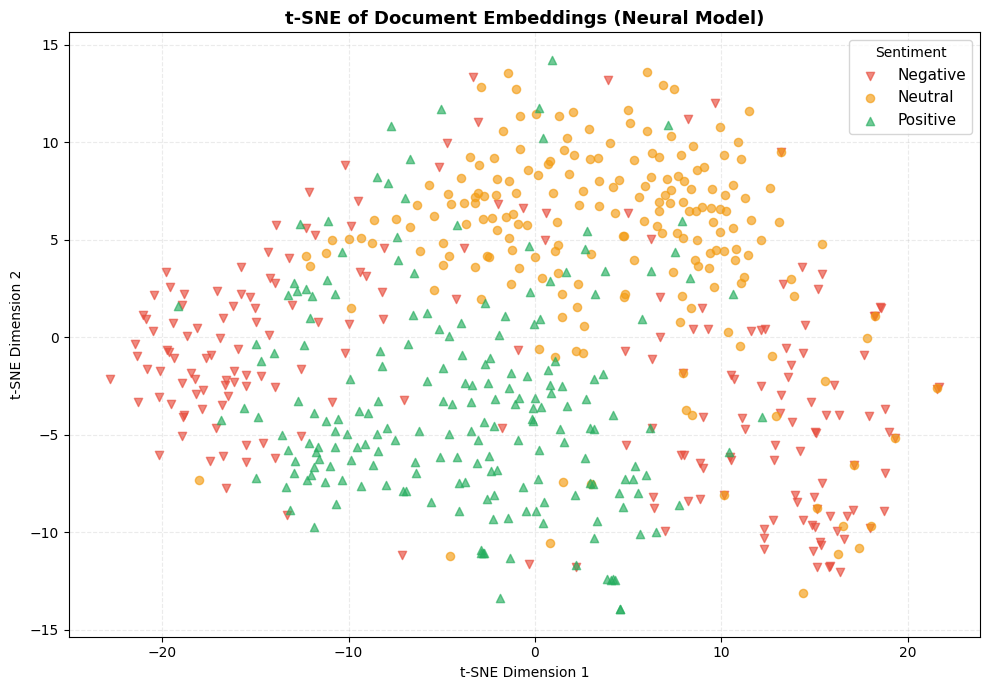

In [32]:
# t-SNE Visualization
np.random.seed(42)
label_arr  = np.array(all_labels)
sample_idx = []

for sentiment in ["negative", "neutral", "positive"]:
    idx    = np.where(label_arr == sentiment)[0]
    chosen = np.random.choice(idx, size=min(200, len(idx)), replace=False)
    sample_idx.extend(chosen.tolist())

sample_idx    = np.array(sample_idx)
sample_vecs   = doc_vectors[sample_idx]
sample_labels = label_arr[sample_idx]

print(f"กำลัง run t-SNE บน {len(sample_idx)} documents...")
tsne   = TSNE(n_components=2, perplexity=40, max_iter=1000,
              learning_rate="auto", init="pca", random_state=42)
vecs2d = tsne.fit_transform(sample_vecs)

color_map  = {"negative": "#e74c3c", "neutral": "#f39c12", "positive": "#27ae60"}
marker_map = {"negative": "v",       "neutral": "o",        "positive": "^"}

fig, ax = plt.subplots(figsize=(10, 7))
for sentiment in ["negative", "neutral", "positive"]:
    mask = sample_labels == sentiment
    ax.scatter(vecs2d[mask, 0], vecs2d[mask, 1],
               c=color_map[sentiment], marker=marker_map[sentiment],
               label=sentiment.capitalize(), alpha=0.65, s=35)

ax.set_title("t-SNE of Document Embeddings (Neural Model)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Sentiment", fontsize=11)
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

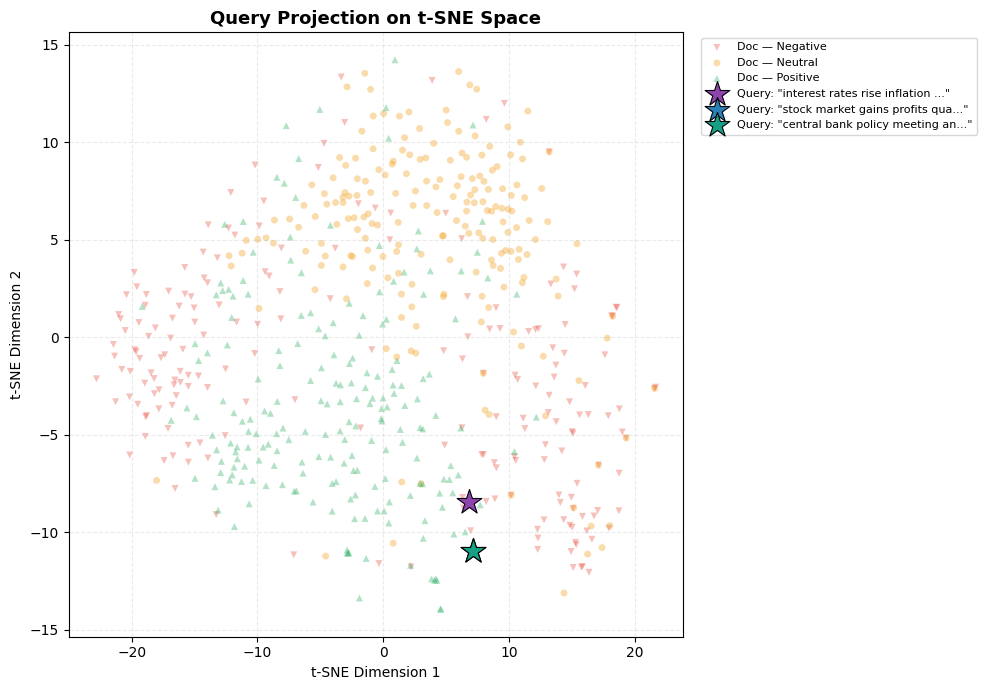

In [33]:
# Query Projection บน t-SNE Space
demo_queries  = [
    "interest rates rise inflation economic growth",
    "stock market gains profits quarterly earnings",
    "central bank policy meeting announcement",
]
query_colors = ["#8e44ad", "#2980b9", "#16a085"]

query_vecs = []
for q in demo_queries:
    seq    = tokenizer.texts_to_sequences([q])
    padded = pad_sequences(seq, maxlen=max_len, padding="post")
    embed  = embedding_layer(padded)
    vec    = tf.reduce_mean(embed, axis=1).numpy()[0]
    vec    = vec / (np.linalg.norm(vec) + 1e-10)
    query_vecs.append(vec)
query_vecs = np.array(query_vecs)

def project_query(q_vec, sample_vecs, vecs2d, k=5):
    sims  = sample_vecs.dot(q_vec)
    top_k = np.argsort(sims)[::-1][:k]
    return vecs2d[top_k].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 7))
for sentiment in ["negative", "neutral", "positive"]:
    mask = sample_labels == sentiment
    ax.scatter(vecs2d[mask, 0], vecs2d[mask, 1],
               c=color_map[sentiment], marker=marker_map[sentiment],
               label=f"Doc — {sentiment.capitalize()}",
               alpha=0.35, s=25, edgecolors="none")

for q, q_vec, color in zip(demo_queries, query_vecs, query_colors):
    proj = project_query(q_vec, sample_vecs, vecs2d, k=5)
    ax.scatter(proj[0], proj[1], c=color, marker="*", s=350,
               edgecolors="black", linewidths=0.8, zorder=5,
               label=f'Query: "{q[:30]}..."')

ax.set_title("Query Projection on t-SNE Space", fontsize=13, fontweight="bold")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()